In [379]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
import numpy as np
import os
from datetime import datetime
import seaborn as sns
from collections import Counter
import plotly.graph_objects as go
import plotly.express as px
from collections import defaultdict

In [380]:
DRUG_COL = 'Drug_name' # 'Non_proprietary_name', 'Drug_name'
DATASET_FILTER = "_pars" # "" or "_pars"
DECISION_FILTER = "approved"

In [381]:
DATASET_DIR = f"./../data/datasets/1995{DATASET_FILTER}/{DECISION_FILTER}"

# EMA = f"{DATASET_DIR}/EMA.csv"
# PMDA = f"{DATASET_DIR}/PMDA.csv"
# SWISSMEDIC = f"{DATASET_DIR}/Swissmedic.csv"
# TGA = f"{DATASET_DIR}/TGA.csv"
# FDA = f"{DATASET_DIR}/FDA.csv"
# HEALTHCANADA = f"{DATASET_DIR}/HealthCanada.csv"
OVERALL = f"{DATASET_DIR}/Overall.csv"

SAVE_DIR = f"./../analysis/1995{DATASET_FILTER}/{DECISION_FILTER}/overlap/{DRUG_COL}"
os.makedirs(SAVE_DIR, exist_ok=True)

In [382]:
# ema = pd.read_csv(EMA)
# pmda = pd.read_csv(PMDA)
# swissmedic = pd.read_csv(SWISSMEDIC)
# tga = pd.read_csv(TGA)
# fda = pd.read_csv(FDA)
# healthcanada = pd.read_csv(HEALTHCANADA)
overall = pd.read_csv(OVERALL)

In [383]:
overall.head(1)

,Administration_route,Application_date,Application_year,Current_status,Dataset,Decision,Decision_date,Decision_year,Disease_class(es),Document_name,...,Marketing_authorisation_holder,Marketing_authorisation_holder_extracted,Marketing_authorisation_number,Non_proprietary_name,Nonclinical_abridged,Orphan_drug_status,Pharmaceutical_form,Procedure_number,Referral_body,Agency
0,subcutaneous,03.06.2013,2013.0,authorised,ema,approved,26.06.2014,2014,"endocrine, nutritional, and metabolic diseases",abasria-epar-public-assessment-report_en.pdf,...,eli lilly regional operations gmbh,eli lilly,ema/chmp/340840/2014,insulin glargine,no,no,solution,emea/h/c/002835/0000,na,EMA


In [384]:
def plot_agency_distribution(dataset, data_col, figsize=(4.2, 4.2), bar_color='darkseagreen', 
                            edge_color='navy', xlabel_fontsize=12, ylabel_fontsize=12):
    plt.figure(figsize=figsize)
    
    agency_counts = dataset.groupby(data_col)['Agency'].nunique()
    agency_counts.value_counts().sort_index().plot(kind='bar', color=bar_color, edgecolor=edge_color)
    
    plt.xlabel(f'$N$ drug agencies', fontsize=xlabel_fontsize)
    plt.ylabel(f'$N$ {data_col.lower().replace("_", " ")}', fontsize=ylabel_fontsize)
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(agency_counts.value_counts().sort_index()):
        plt.text(i, v + max(agency_counts.value_counts()) * 0.001, str(v), 
                 ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{data_col}_agency_distribution.png", dpi=300)
    plt.show()

def create_normalized_heatmap(dataset=overall, data_col='Drug_name', figsize=(5, 4), cmap='Greens'):
    agencies = dataset['Agency'].unique()
    heatmap = pd.DataFrame(0, index=agencies, columns=agencies)

# Get the total number of drugs per agency
    agency_drug_counts = dataset.groupby('Agency')[data_col].nunique()
    for drug in dataset[data_col].unique():
        involved_agencies = dataset[dataset[data_col] == drug]['Agency'].unique()
        for agency1, agency2 in combinations(involved_agencies, 2):
            heatmap.loc[agency1, agency2] += 1
            heatmap.loc[agency2, agency1] += 1

# Normalize by column (x-axis) agency's total drug count
    heatmap_normalized = heatmap.copy()
    for j, agency_col in enumerate(agencies):  # j is column (x-axis)
        for i, agency_row in enumerate(agencies):  # i is row (y-axis)
            if i != j:
            # Divide by the column agency's total drugs
                heatmap_normalized.loc[agency_row, agency_col] = (
                heatmap.loc[agency_row, agency_col] / agency_drug_counts[agency_col]
            )

    plt.figure(figsize=figsize)
    plt.imshow(heatmap_normalized, cmap=cmap, interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(label='Proportion of Column Agency Drugs')
    plt.xticks(ticks=np.arange(len(agencies)), labels=agencies, rotation=45)
    plt.yticks(ticks=np.arange(len(agencies)), labels=agencies)

# Add text with absolute and percentage values
    for i in range(len(agencies)):
        for j in range(len(agencies)):
            if i != j:  # Skip diagonal
                abs_value = int(heatmap.iloc[i, j])
                prop_value = heatmap_normalized.iloc[i, j]
            # text_color = 'white' if prop_value > 0.5 else 'black'
                text_color = "black"
                # round percent to integer if >=10%, else 1 decimal place
                if prop_value >= 0.1:
                    prop_text = f'{prop_value:.0%}'
                else:
                    prop_text = f'{prop_value:.1%}'
                plt.text(j, i, f'{abs_value}\n({prop_text})', 
                    ha='center', va='center', 
                    color=text_color, fontsize=9)

    # plt.title('Shared Drugs (% of horizontal axis agency)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{data_col}_normalized_heatmap.png", dpi=300)
    plt.show()

def analyze_drug_duplicates(dataset, data_col, top_n_drugs=2):

    # Create a subset df with drug names which appear multiple times within the SAME agency
    duplicates_within_agency = dataset[dataset.duplicated(subset=[data_col, 'Agency'], keep=False)]
    
    # Find drug names which are cross-agency duplicates (appear in multiple different agencies)
    cross_agency_duplicates = dataset[dataset.duplicated(subset=[data_col], keep=False)]
    
    # Drop in-agency duplicates from this subset to keep only cross-agency duplicates
    cross_agency_duplicates = cross_agency_duplicates[~cross_agency_duplicates.index.isin(duplicates_within_agency.index)]
    
    # Find the top shared drugs across multiple agencies and create df subset with them
    drug_agency_count = dataset.groupby(data_col)['Agency'].nunique()
    top_shared_drugs = drug_agency_count[drug_agency_count > top_n_drugs].index.tolist()
    top_shared_drugs_df = dataset[dataset[data_col].isin(top_shared_drugs)]
    
    print(20 * "-")
    print(f"{len(dataset):<10} Length of the combined (overall) dataset including all datapoints")
    print(f"{len(duplicates_within_agency):<10} Length of the subset including in-agency duplicates ({data_col} present multiple times within the same agency)")
    print(f"{len(cross_agency_duplicates):<10} Length of the subset including cross-agency duplicates ({data_col} present in multiple different agencies)")
    print(20 * "-")
    print(f"{dataset[data_col].nunique():<10} N of unique {data_col} in the combined dataset")
    print(f"{duplicates_within_agency[data_col].nunique():<10} N of unique {data_col} in the in-agency duplicates subset")
    print(f"{cross_agency_duplicates[data_col].nunique():<10} N of unique {data_col} in the cross-agency duplicates subset")
    
    return {
        'duplicates_within_agency': duplicates_within_agency,
        'cross_agency_duplicates': cross_agency_duplicates,
        'top_shared_drugs_df': top_shared_drugs_df,
        'top_shared_drugs': top_shared_drugs
    }

In [385]:
def analyze_agency_drug_sharing(dataset, data_col='Drug_name', output_file=None):

    agencies = sorted(dataset['Agency'].unique())
    
    # Filter out rows with missing drug names
    dataset_clean = dataset[dataset[data_col].notna()].copy()
    
    # Create a mapping of drug to set of agencies
    drug_to_agencies = dataset_clean.groupby(data_col)['Agency'].apply(set).to_dict()
    
    # Initialize results dictionary
    results = {agency: {} for agency in agencies}
    
    # Prepare output capture
    output_lines = []
    
    # For each agency, analyze its drugs
    for agency in agencies:
        # Get unique drugs for this agency, excluding NaN values
        agency_drugs = dataset_clean[dataset_clean['Agency'] == agency][data_col].unique()
        total_drugs = len(agency_drugs)
        
        if total_drugs == 0:
            continue
        
        # Count how many agencies each drug appears in (beyond the current agency)
        sharing_counts = {}
        for drug in agency_drugs:
            agencies_with_drug = drug_to_agencies.get(drug, set())
            # Count other agencies (excluding current agency)
            n_other_agencies = len(agencies_with_drug) - 1
            sharing_counts[n_other_agencies] = sharing_counts.get(n_other_agencies, 0) + 1
        
        # Calculate percentages
        for n_shared in sharing_counts:
            percentage = (sharing_counts[n_shared] / total_drugs) * 100
            results[agency][n_shared] = percentage
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results).T
    results_df = results_df.fillna(0).sort_index(axis=1)
    
    # Rename columns for clarity
    column_names = {}
    for col in results_df.columns:
        if col == 0:
            column_names[col] = 'Unique to agency'
        elif col == 1:
            column_names[col] = 'Shared with 1 other'
        else:
            column_names[col] = f'Shared with {col} others'
    results_df = results_df.rename(columns=column_names)
    
    # Display results
    def print_and_capture(text):
        print(text)
        output_lines.append(text)
    
    print_and_capture(f"\n{'='*80}")
    print_and_capture(f"Drug Sharing Analysis by Agency (unique deduped entries based on {data_col})")
    print_and_capture(f"{'='*80}\n")
    
    print_and_capture(f"Percentages represent proportion of each agency's unique deduped entries by {data_col}:\n")
    print_and_capture(results_df.round(2).to_string())
    
    # Also print absolute counts
    print_and_capture(f"\n\n{'='*80}")
    print_and_capture(f"Absolute counts (by unique deduped entry in {data_col}):")
    print_and_capture(f"{'='*80}\n")
    
    # Calculate absolute counts
    counts_results = {agency: {} for agency in agencies}
    for agency in agencies:
        agency_drugs = dataset_clean[dataset_clean['Agency'] == agency][data_col].unique()
        total_drugs = len(agency_drugs)
        
        if total_drugs == 0:
            continue
        
        sharing_counts = {}
        for drug in agency_drugs:
            agencies_with_drug = drug_to_agencies.get(drug, set())
            n_other_agencies = len(agencies_with_drug) - 1
            sharing_counts[n_other_agencies] = sharing_counts.get(n_other_agencies, 0) + 1
        
        for n_shared in sharing_counts:
            counts_results[agency][n_shared] = sharing_counts[n_shared]
    
    counts_df = pd.DataFrame(counts_results).T
    counts_df = counts_df.fillna(0).sort_index(axis=1).astype(int)
    counts_df = counts_df.rename(columns=column_names)
    
    print_and_capture(counts_df.to_string())
    
    # Summary statistics
    print_and_capture(f"\n\n{'='*80}")
    print_and_capture(f"Summary Statistics by unique deduped {data_col}:")
    print_and_capture(f"{'='*80}\n")
    
    for agency in agencies:
        total = len(dataset_clean[dataset_clean['Agency'] == agency][data_col])
        total_deduped = dataset_clean[dataset_clean['Agency'] == agency][data_col].nunique()
        unique = counts_df.loc[agency, 'Unique to agency'] if 'Unique to agency' in counts_df.columns else 0
        print_and_capture(f"{agency:15} - Total: {total:4}, Total deduped: {total_deduped:4}, Unique to this agency: {unique:4} ({unique/total_deduped*100:.1f}%)")
    
    # Save to file if output_file is specified
    if output_file:
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write('\n'.join(output_lines))
        print(f"\n Analysis saved to: {output_file}")
    
    return results_df, counts_df

In [386]:
def get_top_duplicated_drugs(dataset, data_col='Drug_name', top_n=15):

    # Filter out rows with missing values in data_col
    dataset_clean = dataset[dataset[data_col].notna()].copy()
    
    # Count occurrences of each drug
    drug_counts = dataset_clean[data_col].value_counts()
    
    # Get top N drugs with most duplicates
    top_drugs = drug_counts.head(top_n).index.tolist()
    
    # Filter dataset for these top drugs
    top_drugs_df = dataset_clean[dataset_clean[data_col].isin(top_drugs)].copy()
    
    # Sort by data_col and then by Agency for easy comparison
    top_drugs_df = top_drugs_df.sort_values([data_col, 'Agency'])
    
    print(f"\nTop {top_n} drugs with most entries (by {data_col}):")
    print(f"{'='*80}\n")
    for i, (drug, count) in enumerate(drug_counts.head(top_n).items(), 1):
        agencies = dataset_clean[dataset_clean[data_col] == drug]['Agency'].unique()
        print(f"{i:2}. {drug:40} - {count:3} entries across {len(agencies)} agencies: {', '.join(sorted(agencies))}")
    
    # save for inspection
    top_drugs_df.to_csv(f"{SAVE_DIR}/top_{top_n}_duplicated_drugs_by_{data_col}.csv", index=False)
    
    return top_drugs_df

# Analyse duplicates

In [387]:
results = analyze_drug_duplicates(dataset=overall, data_col=DRUG_COL, top_n_drugs=10)

--------------------
3120       Length of the combined (overall) dataset including all datapoints
542        Length of the subset including in-agency duplicates (Drug_name present multiple times within the same agency)
1121       Length of the subset including cross-agency duplicates (Drug_name present in multiple different agencies)
--------------------
2030       N of unique Drug_name in the combined dataset
170        N of unique Drug_name in the in-agency duplicates subset
527        N of unique Drug_name in the cross-agency duplicates subset


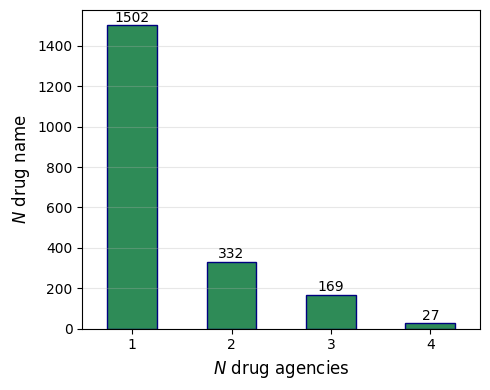

In [388]:
plot_agency_distribution(overall, data_col=DRUG_COL, figsize=(5, 4), bar_color='seagreen', edge_color='navy', xlabel_fontsize=12, ylabel_fontsize=12)

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_6180\3832251816.py:40: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.11006711409395974' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_6180\3832251816.py:40: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5239616613418531' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_6180\3832251816.py:40: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.8402061855670103' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_6180\3832251816.py:40: Futur

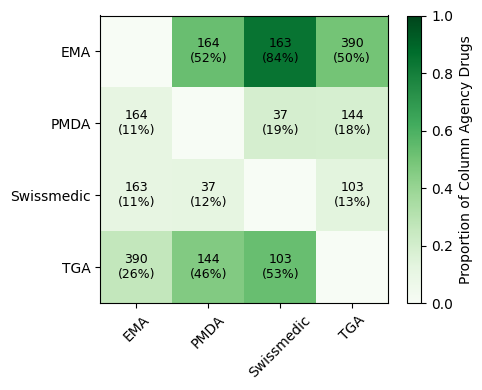

In [389]:
create_normalized_heatmap(dataset=overall, data_col=DRUG_COL, figsize=(5, 4), cmap='Greens')

In [390]:
analyze_agency_drug_sharing(dataset=overall, data_col=DRUG_COL, output_file=f"{SAVE_DIR}/analysis.txt")


Drug Sharing Analysis by Agency (unique deduped entries based on Drug_name)

Percentages represent proportion of each agency's unique deduped entries by Drug_name:

            Unique to agency  Shared with 1 other  Shared with 2 others  Shared with 3 others
EMA                    66.78                20.13                 11.28                  1.81
PMDA                   39.62                19.17                 32.59                  8.63
Swissmedic             11.34                35.05                 39.69                 13.92
TGA                    46.05                30.10                 20.41                  3.44


Absolute counts (by unique deduped entry in Drug_name):

            Unique to agency  Shared with 1 other  Shared with 2 others  Shared with 3 others
EMA                      995                  300                   168                    27
PMDA                     124                   60                   102                    27
Swissmedic             

(            Unique to agency  Shared with 1 other  Shared with 2 others  \
 EMA                66.778523            20.134228             11.275168   
 PMDA               39.616613            19.169329             32.587859   
 Swissmedic         11.340206            35.051546             39.690722   
 TGA                46.045918            30.102041             20.408163   
 
             Shared with 3 others  
 EMA                     1.812081  
 PMDA                    8.626198  
 Swissmedic             13.917526  
 TGA                     3.443878  ,
             Unique to agency  Shared with 1 other  Shared with 2 others  \
 EMA                      995                  300                   168   
 PMDA                     124                   60                   102   
 Swissmedic                22                   68                    77   
 TGA                      361                  236                   160   
 
             Shared with 3 others  
 EMA               

In [391]:
# Get top 15 drugs with most duplicates
top_duplicated_df = get_top_duplicated_drugs(dataset=overall, data_col=DRUG_COL, top_n=15)
top_duplicated_df.head(3)


Top 15 drugs with most entries (by Drug_name):

 1. opdivo                                   -  20 entries across 3 agencies: EMA, PMDA, TGA
 2. comirnaty                                -  18 entries across 4 agencies: EMA, PMDA, Swissmedic, TGA
 3. keytruda                                 -  15 entries across 3 agencies: EMA, PMDA, TGA
 4. actemra                                  -  13 entries across 2 agencies: PMDA, TGA
 5. rinvoq                                   -  12 entries across 4 agencies: EMA, PMDA, Swissmedic, TGA
 6. spikevax                                 -  11 entries across 3 agencies: PMDA, Swissmedic, TGA
 7. enhertu                                  -   9 entries across 4 agencies: EMA, PMDA, Swissmedic, TGA
 8. nuvaxovid                                -   9 entries across 4 agencies: EMA, PMDA, Swissmedic, TGA
 9. avastin                                  -   8 entries across 3 agencies: EMA, PMDA, TGA
10. ultomiris                                -   8 entries acros

,Administration_route,Application_date,Application_year,Current_status,Dataset,Decision,Decision_date,Decision_year,Disease_class(es),Document_name,...,Marketing_authorisation_holder,Marketing_authorisation_holder_extracted,Marketing_authorisation_number,Non_proprietary_name,Nonclinical_abridged,Orphan_drug_status,Pharmaceutical_form,Procedure_number,Referral_body,Agency
1523,intravenous,28.04.2006,2006.0,authorised,japan,approved,30.01.2008,2008,diseases of the musculoskeletal system and con...,000153709.pdf,...,"chugai pharmaceutical co., ltd.",chugai,NaN,tocilizumab,no,no,concentrate,NaN,na,PMDA
1652,subcutaneous,25.08.2016,2016.0,authorised,japan,approved,10.04.2017,2017,diseases of the musculoskeletal system and con...,000224729.pdf,...,"chugai pharmaceutical co., ltd.",chugai,NaN,tocilizumab,yes,no,injection,NaN,NaN,PMDA
1653,subcutaneous,30.11.2016,2016.0,authorised,japan,approved,27.07.2017,2017,diseases of the musculoskeletal system and con...,000224730.pdf,...,"chugai pharmaceutical co., ltd.",chugai,NaN,tocilizumab,yes,yes,injection,NaN,NaN,PMDA


# Create Deduplicated Dataset for Trajectory Analysis

In [392]:
def create_deduplicated_dataset(dataset, data_col='Drug_name', date_col='Decision_date'):
    """
    Deduplicate the dataset by keeping only one instance of each drug per agency.
    For duplicates within the same agency, keep the earliest approval date.
    
    Parameters:
    - dataset: DataFrame with drug approvals
    - data_col: Column name for drug identifier (e.g., 'Drug_name' or 'Non_proprietary_name')
    - date_col: Column name for decision date
    
    Returns:
    - Deduplicated DataFrame
    """
    # Make a copy to avoid modifying the original
    df = dataset.copy()
    
    # Convert date column to datetime
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    
    print(f"Original dataset size: {len(df)}")
    print(f"Unique drugs in original: {df[data_col].nunique()}")
    print(f"\nChecking for duplicates within agencies...")
    
    # Check for duplicates within each agency
    duplicates_within_agency = df[df.duplicated(subset=[data_col, 'Agency'], keep=False)]
    print(f"Rows with duplicates within same agency: {len(duplicates_within_agency)}")
    print(f"Unique drugs affected: {duplicates_within_agency[data_col].nunique()}")
    
    # Sort by date to ensure earliest comes first
    df = df.sort_values([data_col, 'Agency', date_col])
    
    # Keep only the first (earliest) occurrence of each drug-agency combination
    df_deduped = df.drop_duplicates(subset=[data_col, 'Agency'], keep='first')
    
    print(f"\nDeduplicated dataset size: {len(df_deduped)}")
    print(f"Rows removed: {len(df) - len(df_deduped)}")
    print(f"Unique drugs in deduplicated: {df_deduped[data_col].nunique()}")
    
    return df_deduped

In [393]:
# Create deduplicated version of overall dataset for trajectory analysis
overall_deduped = create_deduplicated_dataset(overall, data_col=DRUG_COL, date_col='Decision_date')

# Save the deduplicated dataset
overall_deduped.to_csv(f"{SAVE_DIR}/overall_deduplicated.csv", index=False)
print(f"\nDeduplicated dataset saved to: {SAVE_DIR}/overall_deduplicated.csv")

Original dataset size: 3120
Unique drugs in original: 2030

Checking for duplicates within agencies...
Rows with duplicates within same agency: 542
Unique drugs affected: 170

Deduplicated dataset size: 2781
Rows removed: 339
Unique drugs in deduplicated: 2030

Deduplicated dataset saved to: ./../analysis/1995_pars/approved/overlap/Drug_name/overall_deduplicated.csv


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_6180\3391221100.py:18: UserWarning:

Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



# Analyze Approval Trajectories and Timelines

In [394]:
# First, let's check what date columns are available
print("Columns in overall dataset:")
print(overall_deduped.columns.tolist())
print("\nFirst few rows:")
overall.head(3)

Columns in overall dataset:
['Administration_route', 'Application_date', 'Application_year', 'Current_status', 'Dataset', 'Decision', 'Decision_date', 'Decision_year', 'Disease_class(es)', 'Document_name', 'Drug_class', 'Drug_name', 'Indication_approved', 'Indication_approved_extracted', 'Indication_extended', 'Indication_requested', 'Indication_requested_extracted', 'Marketing_authorisation_holder', 'Marketing_authorisation_holder_extracted', 'Marketing_authorisation_number', 'Non_proprietary_name', 'Nonclinical_abridged', 'Orphan_drug_status', 'Pharmaceutical_form', 'Procedure_number', 'Referral_body', 'Agency']

First few rows:


,Administration_route,Application_date,Application_year,Current_status,Dataset,Decision,Decision_date,Decision_year,Disease_class(es),Document_name,...,Marketing_authorisation_holder,Marketing_authorisation_holder_extracted,Marketing_authorisation_number,Non_proprietary_name,Nonclinical_abridged,Orphan_drug_status,Pharmaceutical_form,Procedure_number,Referral_body,Agency
0,subcutaneous,03.06.2013,2013.0,authorised,ema,approved,26.06.2014,2014,"endocrine, nutritional, and metabolic diseases",abasria-epar-public-assessment-report_en.pdf,...,eli lilly regional operations gmbh,eli lilly,ema/chmp/340840/2014,insulin glargine,no,no,solution,emea/h/c/002835/0000,na,EMA
1,intravenous,30.04.2020,2020.0,authorised,ema,approved,24.06.2021,2021,neoplasms; diseases of the blood and blood-for...,abecma-epar-public-assessment-report_en.pdf,...,celgene europe bv,celgene,ema/409800/2021,idecabtagene vicleucel,no,yes,dispersion,emea/h/c/004662/0000,na,EMA
2,intramuscular,30.11.2012,2012.0,authorised,ema,approved,19.09.2013,2013,mental and behavioural disorders,abilify-maintena-epar-public-assessment-report...,...,otsuka pharmaceutical europe ltd,otsuka,ema/737723/2013,aripiprazole,no,no,powder; solvent,emea/h/c/002755/0000,na,EMA


In [395]:
def analyze_approval_trajectories(dataset, data_col='Drug_name', date_col='Decision_date', min_agencies=2):
    """
    Analyze the order of approvals across agencies for drugs approved by multiple agencies.
    
    Parameters:
    - dataset: DataFrame with drug approvals
    - data_col: Column name for drug identifier
    - date_col: Column name for decision date
    - min_agencies: Minimum number of agencies for a drug to be included
    """
    # Clean dataset
    dataset_clean = dataset[[data_col, 'Agency', date_col]].copy()
    dataset_clean = dataset_clean.dropna(subset=[data_col, date_col])
    
    # Convert date column to datetime
    dataset_clean[date_col] = pd.to_datetime(dataset_clean[date_col], errors='coerce')
    dataset_clean = dataset_clean.dropna(subset=[date_col])
    
    # Filter for drugs approved by multiple agencies
    drug_agency_counts = dataset_clean.groupby(data_col)['Agency'].nunique()
    multi_agency_drugs = drug_agency_counts[drug_agency_counts >= min_agencies].index
    
    multi_agency_df = dataset_clean[dataset_clean[data_col].isin(multi_agency_drugs)].copy()
    
    # Sort by drug and date
    multi_agency_df = multi_agency_df.sort_values([data_col, date_col])
    
    # Create trajectory strings for each drug
    trajectories = []
    drug_timeline_data = []
    
    for drug in multi_agency_df[data_col].unique():
        drug_data = multi_agency_df[multi_agency_df[data_col] == drug].sort_values(date_col)
        agencies = drug_data['Agency'].tolist()
        dates = drug_data[date_col].tolist()
        
        # Create trajectory string (e.g., "EMA -> PMDA -> TGA")
        trajectory = " -> ".join(agencies)
        trajectories.append(trajectory)
        
        # Store timeline data
        drug_timeline_data.append({
            'drug': drug,
            'trajectory': trajectory,
            'agencies': agencies,
            'dates': dates,
            'n_agencies': len(agencies)
        })
    
    # Count trajectory frequencies
    trajectory_counts = Counter(trajectories)
    
    return trajectory_counts, drug_timeline_data, multi_agency_df

def display_top_trajectories(trajectory_counts, top_n=20):
    """Display the most common approval trajectories"""
    print(f"\n{'='*80}")
    print(f"Top {top_n} Most Common Approval Trajectories")
    print(f"{'='*80}\n")
    
    for i, (trajectory, count) in enumerate(trajectory_counts.most_common(top_n), 1):
        n_agencies = trajectory.count('->') + 1
        print(f"{i:2}. [{count:3} drugs, {n_agencies} agencies] {trajectory}")
    
    return pd.DataFrame(trajectory_counts.most_common(top_n), columns=['Trajectory', 'Count'])

def analyze_inter_agency_lags(drug_timeline_data, output_file=None):
    """
    Analyze time lags between consecutive agency approvals
    """
    lags_data = []
    
    for drug_info in drug_timeline_data:
        agencies = drug_info['agencies']
        dates = drug_info['dates']
        
        for i in range(len(agencies) - 1):
            lag_days = (dates[i+1] - dates[i]).days
            lags_data.append({
                'drug': drug_info['drug'],
                'from_agency': agencies[i],
                'to_agency': agencies[i+1],
                'lag_days': lag_days,
                'lag_months': lag_days / 30.44,  # Average days per month
                'from_date': dates[i],
                'to_date': dates[i+1]
            })
    
    lags_df = pd.DataFrame(lags_data)
    
    # Create agency pair column
    lags_df['agency_pair'] = lags_df['from_agency'] + ' -> ' + lags_df['to_agency']
    
    # Summary statistics by agency pair
    print(f"\n{'='*80}")
    print(f"Time Lag Statistics Between Agencies (consecutive approvals)")
    print(f"{'='*80}\n")
    
    summary = lags_df.groupby('agency_pair').agg({
        'lag_days': ['count', 'mean', 'median', 'std', 'min', 'max']
    }).round(1)
    
    summary.columns = ['Count', 'Mean (days)', 'Median (days)', 'Std (days)', 'Min (days)', 'Max (days)']
    summary = summary.sort_values('Count', ascending=False)
    
    print(summary.to_string())
    
    # Also show in months
    print(f"\n{'='*80}")
    print(f"Time Lag Statistics in Months")
    print(f"{'='*80}\n")
    
    summary_months = lags_df.groupby('agency_pair').agg({
        'lag_months': ['count', 'mean', 'median', 'std', 'min', 'max']
    }).round(1)
    
    summary_months.columns = ['Count', 'Mean (months)', 'Median (months)', 'Std (months)', 'Min (months)', 'Max (months)']
    summary_months = summary_months.sort_values('Count', ascending=False)
    
    print(summary_months.to_string())
    
    # Save to file if requested
    if output_file:
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write(f"{'='*80}\n")
            f.write(f"Time Lag Statistics Between Agencies (consecutive approvals) - DAYS\n")
            f.write(f"{'='*80}\n\n")
            f.write(summary.to_string())
            f.write(f"\n\n{'='*80}\n")
            f.write(f"Time Lag Statistics in Months\n")
            f.write(f"{'='*80}\n\n")
            f.write(summary_months.to_string())
        print(f"\nAnalysis saved to: {output_file}")
    
    return lags_df, summary, summary_months

In [396]:
def plot_trajectory_distribution(trajectory_counts_df, top_n=15, figsize=(12, 6)):
    """Plot the distribution of approval trajectories"""
    plt.figure(figsize=figsize)
    
    top_trajectories = trajectory_counts_df.head(top_n)
    
    plt.barh(range(len(top_trajectories)), top_trajectories['Count'], color='seagreen', edgecolor='navy')
    plt.yticks(range(len(top_trajectories)), top_trajectories['Trajectory'])
    plt.xlabel(f'$N$', fontsize=12)
    plt.ylabel('Approval Trajectory', fontsize=12)
    plt.title(f'Top {top_n} Most Common Approval Trajectories', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(top_trajectories['Count']):
        plt.text(v + 0.1, i, str(v), va='center')
    
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/approval_trajectories_top{top_n}.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_lag_heatmap(lags_df, figsize=(8, 6)):
    """Create a heatmap of median lags between agencies"""
    
    # Calculate median lags for each agency pair
    pivot_data = lags_df.groupby(['from_agency', 'to_agency'])['lag_months'].median().reset_index()
    pivot_table = pivot_data.pivot(index='from_agency', columns='to_agency', values='lag_months')
    
    plt.figure(figsize=figsize)
    sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='YlOrRd', 
                cbar_kws={'label': 'Median Lag (months)'},
                linewidths=0.5, linecolor='gray')
    plt.title('Median Time Lag Between Agencies (months)\nFrom (row) to (column)', 
              fontsize=12, fontweight='bold')
    plt.xlabel('To Agency', fontsize=11)
    plt.ylabel('From Agency', fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/approval_lags_heatmap.png", dpi=300, bbox_inches='tight')
    plt.show()

In [397]:
# Run the trajectory analysis using the DEDUPLICATED dataset
trajectory_counts, drug_timeline_data, multi_agency_df = analyze_approval_trajectories(
    dataset=overall_deduped, 
    data_col=DRUG_COL, 
    date_col='Decision_date', 
    min_agencies=1
)

print(f"\nUsing {DRUG_COL} for trajectory analysis")
print(f"Drugs approved by at least 1 agency: {len(drug_timeline_data)}")
print(f"Total unique trajectories: {len(trajectory_counts)}")


Using Drug_name for trajectory analysis
Drugs approved by at least 1 agency: 1998
Total unique trajectories: 44


In [398]:
# Display top trajectories
trajectory_df = display_top_trajectories(trajectory_counts, top_n=10)


Top 10 Most Common Approval Trajectories

 1. [965 drugs, 1 agencies] EMA
 2. [372 drugs, 1 agencies] TGA
 3. [182 drugs, 2 agencies] EMA -> TGA
 4. [124 drugs, 1 agencies] PMDA
 5. [ 59 drugs, 2 agencies] EMA -> Swissmedic
 6. [ 36 drugs, 3 agencies] EMA -> TGA -> PMDA
 7. [ 31 drugs, 3 agencies] EMA -> PMDA -> TGA
 8. [ 28 drugs, 3 agencies] EMA -> TGA -> Swissmedic
 9. [ 24 drugs, 3 agencies] EMA -> Swissmedic -> TGA
10. [ 23 drugs, 2 agencies] EMA -> PMDA


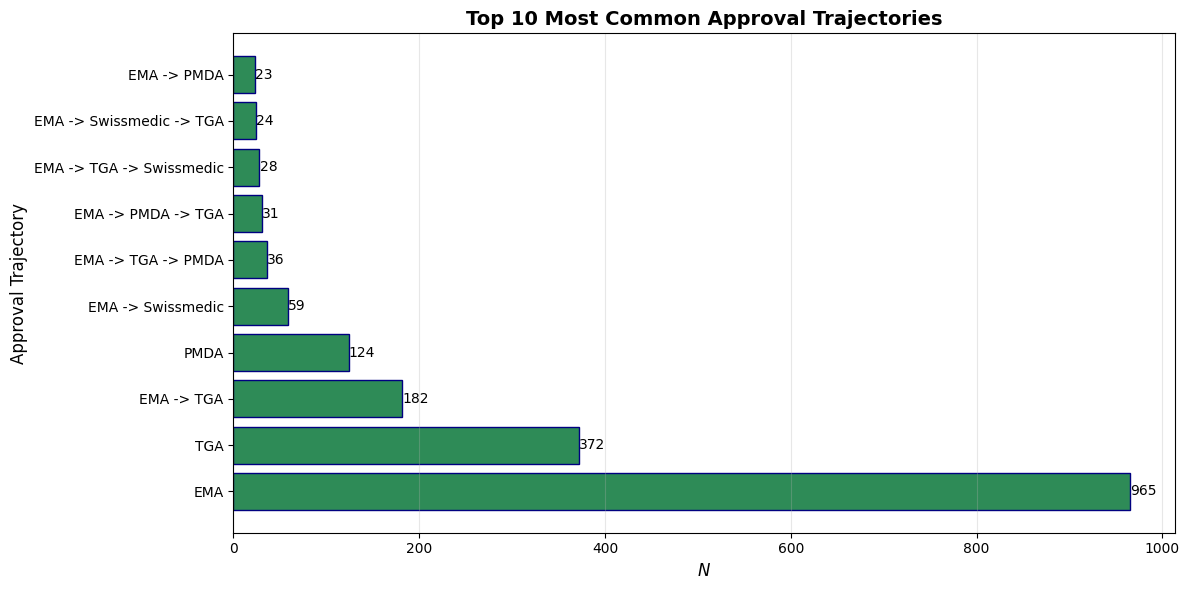

In [399]:
# Plot trajectory distribution
plot_trajectory_distribution(trajectory_df, top_n=10)

In [400]:
# Analyze inter-agency lags
lags_df, lags_summary, lags_summary_months = analyze_inter_agency_lags(
    drug_timeline_data, 
    output_file=f"{SAVE_DIR}/approval_lags_analysis.txt"
)


Time Lag Statistics Between Agencies (consecutive approvals)

                    Count  Mean (days)  Median (days)  Std (days)  Min (days)  Max (days)
agency_pair                                                                              
EMA -> TGA            275        633.3          291.0       813.1           6        4748
EMA -> Swissmedic      99        518.0          314.0       635.1           6        3500
EMA -> PMDA            66        424.3          159.5       884.0           0        6210
TGA -> PMDA            55        819.6          505.0       904.2          14        4163
PMDA -> TGA            52        648.9          310.0       817.9           0        3773
TGA -> Swissmedic      49        289.0          124.0       409.0           1        2006
PMDA -> EMA            40        314.9           87.0       517.0           6        2423
Swissmedic -> TGA      36        315.6          167.0       333.1           2        1152
TGA -> EMA             30        188.

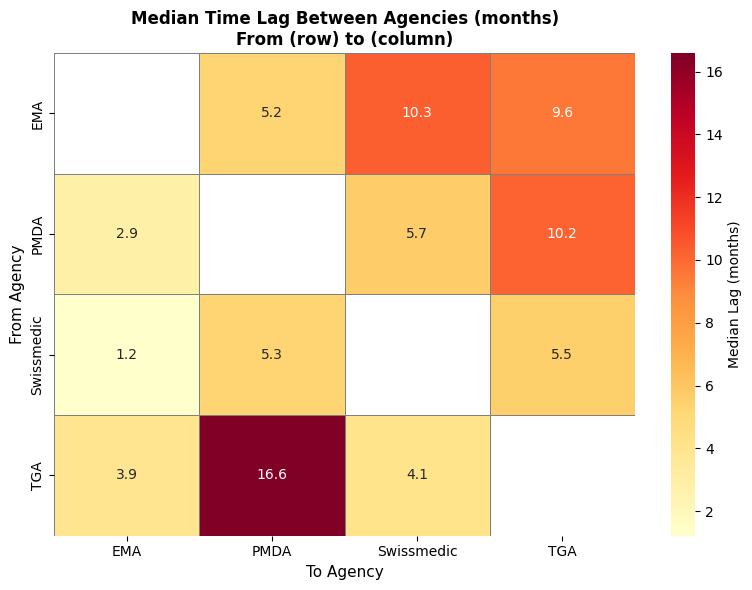

In [401]:
# Plot lag heatmap
plot_lag_heatmap(lags_df)

In [402]:
# View detailed lag data
print("\nSample of drugs with their approval sequences and lags:")
lags_df[['drug', 'from_agency', 'to_agency', 'lag_days', 'lag_months', 'from_date', 'to_date']].head(10)


Sample of drugs with their approval sequences and lags:


,drug,from_agency,to_agency,lag_days,lag_months,from_date,to_date
0,abilify maintena,EMA,TGA,306,10.052562,2013-09-19,2014-07-22
1,abraxane,EMA,TGA,2034,66.819974,2008-01-11,2013-08-06
2,abraxane,TGA,PMDA,2192,72.010512,2013-08-06,2019-08-07
3,abrysvo,EMA,TGA,244,8.015769,2023-07-20,2024-03-20
4,abrysvo,TGA,Swissmedic,156,5.124836,2024-03-20,2024-08-23
5,actemra,PMDA,TGA,1079,35.446781,2008-01-30,2011-01-13
6,adakveo,EMA,TGA,257,8.442838,2020-07-23,2021-04-06
7,adcetris,EMA,PMDA,487,15.998686,2012-07-19,2013-11-18
8,adcetris,PMDA,TGA,31,1.018397,2013-11-18,2013-12-19
9,adempas,PMDA,EMA,55,1.806833,2013-11-29,2014-01-23


In [403]:
# Save detailed trajectory and lag data
lags_df.to_csv(f"{SAVE_DIR}/approval_lags_detailed.csv", index=False)
trajectory_df.to_csv(f"{SAVE_DIR}/approval_trajectories.csv", index=False)

print(f"\nFiles saved to {SAVE_DIR}:")


Files saved to ./../analysis/1995_pars/approved/overlap/Drug_name:


-------

In [404]:

def create_multilevel_sankey(drug_timeline_data, max_levels=4, min_flow=1):
    """
    Create a multi-level Sankey showing position-based flows (1st approval, 2nd approval, etc.)
    
    Parameters:
    - drug_timeline_data: List of drug trajectory dictionaries
    - max_levels: Maximum number of approval positions to show
    - min_flow: Minimum number of drugs for a flow to be displayed
    """
    
    # Count flows with position information
    flow_counts = defaultdict(int)
    
    for drug_info in drug_timeline_data:
        agencies = drug_info['agencies'][:max_levels]  # Limit to max_levels
        
        # Create flows between consecutive agencies
        for i in range(len(agencies) - 1):
            from_node = f"{agencies[i]}_pos{i+1}"
            to_node = f"{agencies[i+1]}_pos{i+2}"
            flow_counts[(from_node, to_node)] += 1
    
    # Filter by minimum flow
    filtered_flows = {k: v for k, v in flow_counts.items() if v >= min_flow}
    
    # Create node list with position labels
    all_nodes = set()
    for (from_node, to_node) in filtered_flows.keys():
        all_nodes.add(from_node)
        all_nodes.add(to_node)
    
    # Sort nodes by position and then by agency
    nodes_list = sorted(list(all_nodes), 
                       key=lambda x: (int(x.split('_pos')[1]), x.split('_pos')[0]))
    node_to_idx = {node: idx for idx, node in enumerate(nodes_list)}
    
    # Agency colors
    agency_colors_base = {
        'EMA': 'rgb(31, 119, 180)',
        'FDA': 'rgb(255, 127, 14)',
        'PMDA': 'rgb(44, 160, 44)',
        'TGA': 'rgb(214, 39, 40)',
        'Swissmedic': 'rgb(148, 103, 189)',
        'HealthCanada': 'rgb(140, 86, 75)'
    }
    
    # Prepare Sankey data
    sources = []
    targets = []
    values = []
    link_colors = []
    
    for (from_node, to_node), count in filtered_flows.items():
        sources.append(node_to_idx[from_node])
        targets.append(node_to_idx[to_node])
        values.append(count)
        
        # Link color based on source agency
        from_agency = from_node.split('_pos')[0]
        base_color = agency_colors_base.get(from_agency, 'rgb(128, 128, 128)')
        link_color = base_color.replace('rgb', 'rgba').replace(')', ', 0.3)')
        link_colors.append(link_color)
    
    # Calculate incoming and outgoing flows for each node
    node_incoming = defaultdict(int)
    node_outgoing = defaultdict(int)
    
    for (from_node, to_node), count in filtered_flows.items():
        node_outgoing[from_node] += count
        node_incoming[to_node] += count
    
    # For first column nodes, calculate total drugs at that position
    # (including those that didn't continue to next agency)
    node_total_at_position = defaultdict(int)
    for drug_info in drug_timeline_data:
        agencies = drug_info['agencies'][:max_levels]
        # Only count the first agency for position 1
        if len(agencies) > 0:
            first_agency = agencies[0]
            node = f"{first_agency}_pos1"
            node_total_at_position[node] += 1
        # For other positions, count normally
        for i in range(1, len(agencies)):
            node = f"{agencies[i]}_pos{i+1}"
            node_total_at_position[node] += 1
    
    # Node labels and colors
    node_labels = []
    node_colors = []
    node_x = []
    node_y = []
    
    for node in nodes_list:
        agency, pos = node.split('_pos')
        incoming = node_incoming.get(node, 0)
        outgoing = node_outgoing.get(node, 0)
        
        # For first column (pos=1), show total drugs at this position instead of 0
        if int(pos) == 1:
            total = node_total_at_position.get(node, incoming)
            node_labels.append(f"{agency} ({total})")
        else:
            node_labels.append(f"{agency} ({incoming})")
        
        base_color = agency_colors_base.get(agency, 'rgb(128, 128, 128)')
        node_colors.append(base_color.replace('rgb', 'rgba').replace(')', ', 0.8)'))
        
        # Position nodes
        position = int(pos) - 1
        node_x.append(position / (max_levels - 1))
    
    # Create Sankey
    fig = go.Figure(data=[go.Sankey(
        arrangement='fixed',
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=node_labels,
            color=node_colors,
            x=node_x
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors,
            customdata=[f"{nodes_list[s].split('_pos')[0]} → {nodes_list[t].split('_pos')[0]}<br>{v} drugs" 
                       for s, t, v in zip(sources, targets, values)],
            hovertemplate='%{customdata}<extra></extra>'
        )
    )])
    
    fig.update_layout(
        title={
            # 'text': "Drug Approval Flow by Sequential Position",
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 20, 'family': 'Arial, sans-serif', 'color': "#26323d"}
        },
        font=dict(size=14, family='Arial, sans-serif'),
        plot_bgcolor='white',
        paper_bgcolor='white',
        height=700,
        margin=dict(l=20, r=20, t=80, b=20)
    )
    
    return fig

In [405]:
# Create multi-level Sankey showing position-based flows 
# (1st approval → 2nd approval → 3rd approval, etc.)
multilevel_fig = create_multilevel_sankey(
    drug_timeline_data, 
    max_levels=4, 
    min_flow=1
)

multilevel_fig.show()

# Save as interactive HTML
multilevel_fig.write_html(f"{SAVE_DIR}/sankey_approval_flow_multilevel.html")
print(f"Multi-level Sankey diagram saved to: {SAVE_DIR}/sankey_approval_flow_multilevel.html")

width = 800 if DATASET_FILTER == "_pars" else 1100
height = 500 if DATASET_FILTER == "_pars" else 700
try:
    multilevel_fig.write_image(f"{SAVE_DIR}/sankey_approval_flow_multilevel.png", width=width, height=height, scale=2)
    print(f"Multi-level Sankey diagram (PNG) saved to: {SAVE_DIR}/sankey_approval_flow_multilevel.png")
except Exception as e:
    print(f"Could not save PNG: {e}")
    print("Install kaleido to enable PNG export: pip install kaleido")

Multi-level Sankey diagram saved to: ./../analysis/1995_pars/approved/overlap/Drug_name/sankey_approval_flow_multilevel.html
Multi-level Sankey diagram (PNG) saved to: ./../analysis/1995_pars/approved/overlap/Drug_name/sankey_approval_flow_multilevel.png
